<a href="https://colab.research.google.com/github/busetas/Roketsan_Sensor/blob/main/04_GPS_INS_F%C3%BCzyonu_Lokalizasyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Otonom kara araçlarında (AGV) en yaygın kullanılan konumlandırma mimarilerinden biri olan INS (Inertial Navigation System) + GPS Sensör Füzyonu uygulamasını ele alacağız.

**Pedagojik Konsept ve Senaryo**

- INS (Ataletsel Navigasyon / Dead Reckoning): Araç üzerindeki ivmeölçer ve jiroskop (veya tekerlek odometrisi) verilerini kullanarak yüksek frekansta ($100\text{ Hz}$) bağıl konum hesaplar.

Problem: Sensör hataları zamanla birikir (drift/sapma yapar), araç rotadan kayar.

- GPS (Küresel Konumlandırma): Düşük frekansta ($1\text{ Hz}$) mutlak konum ($x, y$) verir.

Problem: Gürültülüdür ve sıklıkla gecikmelidir, ancak zamanla biriken bir sapması (drift) yoktur.

- EKF Füzyonu: INS ile yüksek frekansta tahmin yapıp, GPS verisi geldikçe EKF güncellemesi uygulayarak biriken hatayı sıfırlar.

**Python Uygulama Kodu**

Aşağıdaki kod, düzgün dairesel bir rotada ilerleyen bir aracın sadece INS (Drift'li), sadece GPS (Gürültülü) ve EKF Füzyon sonuçlarını karşılaştırmalı olarak simüle etmektedir.


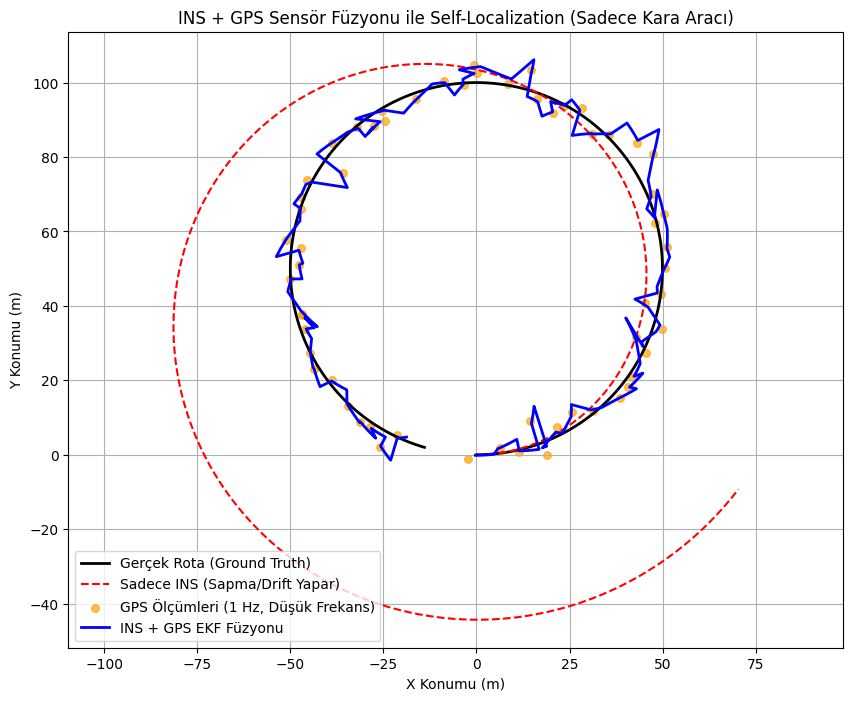

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. ARAÇ SİMÜLASYONU VE SENSÖR ÜRETİCİ
# ==========================================
class VehicleSimulation:
    def __init__(self, dt_ins=0.01, dt_gps=1.0):
        self.dt_ins = dt_ins    # INS Örnekleme: 100 Hz (0.01s)
        self.dt_gps = dt_gps    # GPS Örnekleme: 1 Hz (1.0s)

        # Sensör Hata Parametreleri
        self.gyro_bias = 0.02          # Jiroskop sapması (rad/s)
        self.gyro_noise = 0.005        # Jiroskop gürültüsü
        self.acc_bias = 0.1            # İvmeölçer sapması (m/s^2)
        self.acc_noise = 0.05          # İvmeölçer gürültüsü
        self.gps_noise = 2.5           # GPS konum gürültüsü (m)

    def generate_data(self, total_time=60.0):
        steps = int(total_time / self.dt_ins)

        # Gerçek Durumlar (Ground Truth): [x, y, v, yaw]
        true_states = []
        ins_measurements = []
        gps_measurements = []

        # Başlangıç değerleri (Dairesel hareket)
        x, y, v, yaw = 0.0, 0.0, 5.0, 0.0
        omega = 0.1  # Dönüş hızı (rad/s)

        for i in range(steps):
            t = i * self.dt_ins

            # Gerçek Hareket (Dairesel)
            yaw += omega * self.dt_ins
            x += v * np.cos(yaw) * self.dt_ins
            y += v * np.sin(yaw) * self.dt_ins
            true_states.append([x, y, v, yaw])

            # INS Ölçümü (Gürültü + Sapma/Bias Eklendi)
            measured_omega = omega + self.gyro_bias + np.random.normal(0, self.gyro_noise)
            # İvme = v * omega (Merkezcil ivme) + teğetsel ivme (0)
            measured_acc = 0.0 + self.acc_bias + np.random.normal(0, self.acc_noise)
            ins_measurements.append([measured_acc, measured_omega])

            # GPS Ölçümü (Düşük frekansta, gürültülü mutlak konum)
            if i % int(self.dt_gps / self.dt_ins) == 0:
                gps_x = x + np.random.normal(0, self.gps_noise)
                gps_y = y + np.random.normal(0, self.gps_noise)
                gps_measurements.append([t, gps_x, gps_y])

        return np.array(true_states), np.array(ins_measurements), np.array(gps_measurements)


# ==========================================
# 2. INS/GPS SENSÖR FÜZYONU (EKF)
# ==========================================
class INS_GPS_EKF:
    def __init__(self, dt_ins, gps_noise):
        self.dt = dt_ins

        # Durum Vektörü: [x, y, v, yaw]^T
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 1.0

        # Süreç Gürültüsü (Process Noise Q)
        self.Q = np.diag([0.05, 0.05, 0.1, 0.02])

        # GPS Ölçüm Gürültüsü (Measurement Noise R)
        self.R = np.diag([gps_noise**2, gps_noise**2])

        # GPS Ölçüm Matrisi H (Sadece x ve y'yi ölçer)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

    def initialize(self, x0, y0, v0, yaw0):
        self.x = np.array([[x0], [y0], [v0], [yaw0]])

    def predict_ins(self, acc_meas, gyro_meas):
        """100 Hz INS Ölçümü ile Tahmin Adımı (Dead Reckoning)"""
        px, py, v, yaw = self.x[0,0], self.x[1,0], self.x[2,0], self.x[3,0]

        # Non-Lineer Kinematik Model
        px_new = px + v * np.cos(yaw) * self.dt
        py_new = py + v * np.sin(yaw) * self.dt
        v_new = v + acc_meas * self.dt
        yaw_new = yaw + gyro_meas * self.dt

        self.x = np.array([[px_new], [py_new], [v_new], [yaw_new]])

        # Modelin Jacobian Matrisi (F)
        F = np.array([
            [1, 0, np.cos(yaw)*self.dt, -v*np.sin(yaw)*self.dt],
            [0, 1, np.sin(yaw)*self.dt,  v*np.cos(yaw)*self.dt],
            [0, 0, 1,                   0],
            [0, 0, 0,                   1]
        ])

        # Belirsizlik Yayılımı
        self.P = F @ self.P @ F.T + self.Q

    def update_gps(self, gps_x, gps_y):
        """1 Hz GPS Ölçümü Geldiğinde Düzeltme Adımı"""
        z = np.array([[gps_x], [gps_y]])

        # Beklenen Ölçüm (Durum vektöründeki x ve y)
        z_pred = self.H @ self.x

        # Yenilik (Innovation)
        y = z - z_pred

        # Kalman Kazancı (K)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Durum ve Kovaryans Güncelleme
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P


# ==========================================
# 3. ÇALIŞTIRMA VE GÖRSELLEŞTİRME
# ==========================================
if __name__ == "__main__":
    dt_ins = 0.01
    dt_gps = 1.0

    # 1. Simülasyon Verisi Üret
    sim = VehicleSimulation(dt_ins=dt_ins, dt_gps=dt_gps)
    true_states, ins_meas, gps_meas = sim.generate_data(total_time=60.0)

    # 2. Sadece INS (Dead Reckoning) Hesabı - Füzyonsuz
    dead_reckoning = []
    dr_x, dr_y, dr_v, dr_yaw = 0.0, 0.0, 5.0, 0.0
    for acc, gyro in ins_meas:
        dr_yaw += gyro * dt_ins
        dr_v += acc * dt_ins
        dr_x += dr_v * np.cos(dr_yaw) * dt_ins
        dr_y += dr_v * np.sin(dr_yaw) * dt_ins
        dead_reckoning.append([dr_x, dr_y])
    dead_reckoning = np.array(dead_reckoning)

    # 3. EKF Sensör Füzyonu
    ekf = INS_GPS_EKF(dt_ins, sim.gps_noise)
    ekf.initialize(x0=0, y0=0, v0=5.0, yaw0=0)

    ekf_path = []
    gps_counter = 0

    for i in range(len(ins_meas)):
        t = i * dt_ins
        acc, gyro = ins_meas[i]

        # 1. Yüksek frekansta (100Hz) INS Tahmini
        ekf.predict_ins(acc, gyro)

        # 2. GPS zamanı geldiğinde (1Hz) Düzeltme
        if gps_counter < len(gps_meas) and abs(t - gps_meas[gps_counter, 0]) < 1e-5:
            gps_x = gps_meas[gps_counter, 1]
            gps_y = gps_meas[gps_counter, 2]
            ekf.update_gps(gps_x, gps_y)
            gps_counter += 1

        ekf_path.append(ekf.x[:2].flatten())

    ekf_path = np.array(ekf_path)

    # 4. Çizim
    plt.figure(figsize=(10, 8))
    plt.plot(true_states[:, 0], true_states[:, 1], 'k-', linewidth=2, label='Gerçek Rota (Ground Truth)')
    plt.plot(dead_reckoning[:, 0], dead_reckoning[:, 1], 'r--', linewidth=1.5, label='Sadece INS (Sapma/Drift Yapar)')
    plt.scatter(gps_meas[:, 1], gps_meas[:, 2], color='orange', alpha=0.7, s=30, label='GPS Ölçümleri (1 Hz, Düşük Frekans)')
    plt.plot(ekf_path[:, 0], ekf_path[:, 1], 'b-', linewidth=2, label='INS + GPS EKF Füzyonu')

    plt.title('INS + GPS Sensör Füzyonu ile Self-Localization (Sadece Kara Aracı)')
    plt.xlabel('X Konumu (m)')
    plt.ylabel('Y Konumu (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

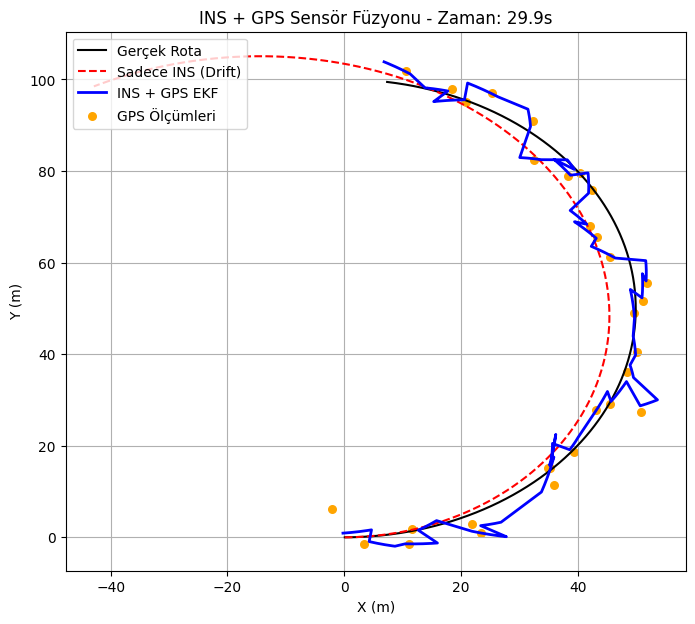

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# Simülasyon Verisi ve Parametreleri
dt_ins, dt_gps = 0.02, 1.0
total_time = 30.0
steps = int(total_time / dt_ins)

x, y, v, yaw = 0.0, 0.0, 5.0, 0.0
dr_x, dr_y, dr_v, dr_yaw = 0.0, 0.0, 5.0, 0.0
ekf_state = np.array([[0.0], [0.0], [5.0], [0.0]])

P = np.eye(4)
Q = np.diag([0.05, 0.05, 0.1, 0.02])
R = np.diag([2.5**2, 2.5**2])
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

true_hist, ins_hist, ekf_hist, gps_hist = [], [], [], []

fig, ax = plt.subplots(figsize=(8, 7))

# Canlı Simülasyon Döngüsü
for i in range(steps):
    t = i * dt_ins

    # --- True ---
    yaw += 0.1 * dt_ins
    x += v * np.cos(yaw) * dt_ins
    y += v * np.sin(yaw) * dt_ins
    true_hist.append([x, y])

    # --- INS ---
    measured_omega = 0.1 + 0.02 + np.random.normal(0, 0.005)
    measured_acc = 0.0 + 0.1 + np.random.normal(0, 0.05)
    dr_yaw += measured_omega * dt_ins
    dr_v += measured_acc * dt_ins
    dr_x += dr_v * np.cos(dr_yaw) * dt_ins
    dr_y += dr_v * np.sin(dr_yaw) * dt_ins
    ins_hist.append([dr_x, dr_y])

    # --- EKF Predict ---
    px, py, ev, eyaw = ekf_state.flatten()
    ekf_state = np.array([
        [px + ev * np.cos(eyaw) * dt_ins],
        [py + ev * np.sin(eyaw) * dt_ins],
        [ev + measured_acc * dt_ins],
        [eyaw + measured_omega * dt_ins]
    ])
    F = np.array([
        [1, 0, np.cos(eyaw)*dt_ins, -ev*np.sin(eyaw)*dt_ins],
        [0, 1, np.sin(eyaw)*dt_ins,  ev*np.cos(eyaw)*dt_ins],
        [0, 0, 1, 0], [0, 0, 0, 1]
    ])
    P = F @ P @ F.T + Q

    # --- GPS Update ---
    if i % int(dt_gps / dt_ins) == 0:
        gx = x + np.random.normal(0, 2.5)
        gy = y + np.random.normal(0, 2.5)
        gps_hist.append([gx, gy])

        z = np.array([[gx], [gy]])
        y_innov = z - H @ ekf_state
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        ekf_state += K @ y_innov
        P = (np.eye(4) - K @ H) @ P

    ekf_hist.append([ekf_state[0, 0], ekf_state[1, 0]])

    # --- HER 5 ADIMDA BİR EKRANI TEMİZLE VE ÇİZ ---
    if i % 5 == 0:
        ax.clear()

        th = np.array(true_hist)
        ih = np.array(ins_hist)
        eh = np.array(ekf_hist)

        ax.plot(th[:, 0], th[:, 1], 'k-', label='Gerçek Rota')
        ax.plot(ih[:, 0], ih[:, 1], 'r--', label='Sadece INS (Drift)')
        ax.plot(eh[:, 0], eh[:, 1], 'b-', linewidth=2, label='INS + GPS EKF')

        if len(gps_hist) > 0:
            gh = np.array(gps_hist)
            ax.scatter(gh[:, 0], gh[:, 1], color='orange', s=30, label='GPS Ölçümleri')

        ax.set_title(f"INS + GPS Sensör Füzyonu - Zaman: {t:.1f}s")
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.grid(True)
        ax.legend(loc='upper left')

        # Notebook hücresini günceller
        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

plt.close(fig)

GPS kesintisi (GPS-Denied Environment), otonom araçlarda tüneller, kapalı otoparklar, şehir içi binalar arası (urban canyon) veya jammer/karıştırma kaynaklı durumlar için en kritik senaryolardan biridir.

Bu senaryoda:

- Araç tünele girdiğinde (örneğin 15. - 25. saniyeler arasında): GPS güncellemeleri tamamen kesilir.

- EKF'nin Kovaryansı ($P$ matrisi) Büyür: Filtre GPS'ten doğrulama alamadığı için kendi tahminine olan güveni düşer (belirsizlik halkası/kovaryans büyür).

- INS Tek Başına Kalır: Bu süre boyunca araç sadece INS (Dead Reckoning) ile konum kestirimi yapar ve hatası yavaşça birikmeye devam eder.

- Tünelden Çıkış: GPS verisi tekrar geldiğinde EKF ani bir düzeltme (reset) yaparak aracı gerçek rotasına yeniden oturtur.

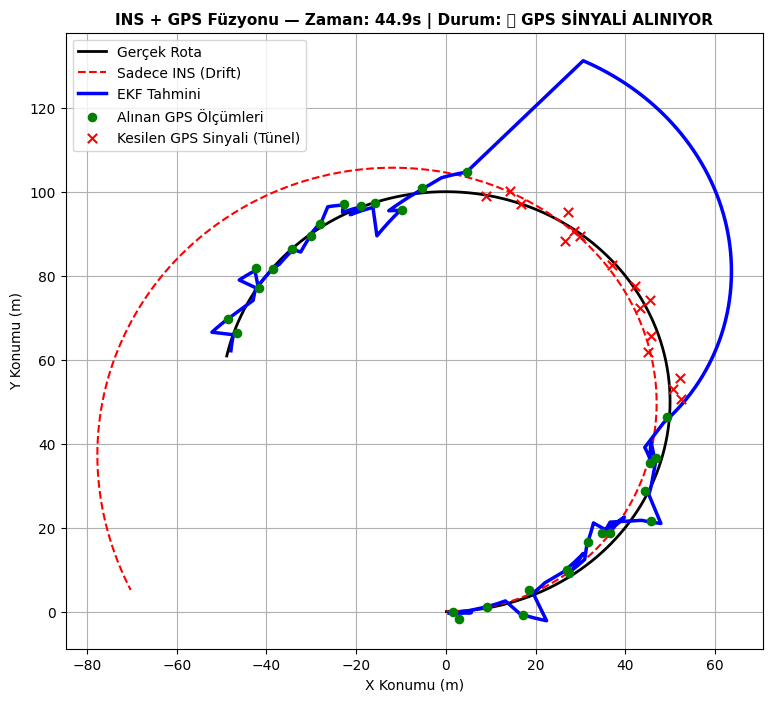

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# ==========================================
# 1. SİMÜLASYON PARAMETRELERİ
# ==========================================
dt_ins = 0.02   # INS: 50 Hz
dt_gps = 1.0    # GPS: 1 Hz
total_time = 45.0
steps = int(total_time / dt_ins)

# GPS Kesintisi (Tünel) Zaman Aralığı (Saniye)
tunnel_start_time = 15.0
tunnel_end_time = 30.0

# Sensör Parametreleri
gyro_bias, gyro_noise = 0.015, 0.005
acc_bias, acc_noise = 0.08, 0.04
gps_noise = 2.0

# Başlangıç Durumları
x, y, v, yaw = 0.0, 0.0, 5.0, 0.0
dr_x, dr_y, dr_v, dr_yaw = 0.0, 0.0, 5.0, 0.0
ekf_state = np.array([[0.0], [0.0], [5.0], [0.0]])

# EKF Matrisleri
P = np.eye(4) * 1.0
Q = np.diag([0.05, 0.05, 0.1, 0.02])
R = np.diag([gps_noise**2, gps_noise**2])
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

# Veri Geçmişi
true_hist, ins_hist, ekf_hist, gps_hist = [], [], [], []
tunnel_gps_lost_pts = [] # Tünelde kaçırılan GPS noktaları

fig, ax = plt.subplots(figsize=(9, 8))

# ==========================================
# 2. CANLI SİMÜLASYON DÖNGÜSÜ
# ==========================================
for i in range(steps):
    t = i * dt_ins

    # --- A. Gerçek Rota (Dairesel) ---
    yaw += 0.1 * dt_ins
    x += v * np.cos(yaw) * dt_ins
    y += v * np.sin(yaw) * dt_ins
    true_hist.append([x, y])

    # --- B. INS Ölçümü ve Dead Reckoning ---
    measured_omega = 0.1 + gyro_bias + np.random.normal(0, gyro_noise)
    measured_acc = 0.0 + acc_bias + np.random.normal(0, acc_noise)

    dr_yaw += measured_omega * dt_ins
    dr_v += measured_acc * dt_ins
    dr_x += dr_v * np.cos(dr_yaw) * dt_ins
    dr_y += dr_v * np.sin(dr_yaw) * dt_ins
    ins_hist.append([dr_x, dr_y])

    # --- C. EKF Tahmin (Predict) Adımı ---
    px, py, ev, eyaw = ekf_state.flatten()
    ekf_state = np.array([
        [px + ev * np.cos(eyaw) * dt_ins],
        [py + ev * np.sin(eyaw) * dt_ins],
        [ev + measured_acc * dt_ins],
        [eyaw + measured_omega * dt_ins]
    ])
    F = np.array([
        [1, 0, np.cos(eyaw)*dt_ins, -ev*np.sin(eyaw)*dt_ins],
        [0, 1, np.sin(eyaw)*dt_ins,  ev*np.cos(eyaw)*dt_ins],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    P = F @ P @ F.T + Q

    # --- D. GPS Ölçümü ve Tünel (GPS-Denied) Kontrolü ---
    is_in_tunnel = (tunnel_start_time <= t <= tunnel_end_time)

    if i % int(dt_gps / dt_ins) == 0:
        gx = x + np.random.normal(0, gps_noise)
        gy = y + np.random.normal(0, gps_noise)

        if not is_in_tunnel:
            # Tünel Dışında: GPS Ölçümünü Kullan ve EKF Güncelle
            gps_hist.append([gx, gy])

            z = np.array([[gx], [gy]])
            y_innov = z - H @ ekf_state
            S = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(S)

            ekf_state += K @ y_innov
            P = (np.eye(4) - K @ H) @ P
        else:
            # Tünel İçinde: GPS Var Ama Sinyal Alınamıyor! (Sadece görselleştirme için sakla)
            tunnel_gps_lost_pts.append([gx, gy])

    ekf_hist.append([ekf_state[0, 0], ekf_state[1, 0]])

    # --- E. Görselleştirme Güncelleme (Her 5 adımda bir) ---
    if i % 5 == 0:
        ax.clear()

        th = np.array(true_hist)
        ih = np.array(ins_hist)
        eh = np.array(ekf_hist)

        # Çizimler
        ax.plot(th[:, 0], th[:, 1], 'k-', linewidth=2, label='Gerçek Rota')
        ax.plot(ih[:, 0], ih[:, 1], 'r--', linewidth=1.5, label='Sadece INS (Drift)')
        ax.plot(eh[:, 0], eh[:, 1], 'b-', linewidth=2.5, label='EKF Tahmini')

        # Başarılı GPS Noktaları
        if len(gps_hist) > 0:
            gh = np.array(gps_hist)
            ax.scatter(gh[:, 0], gh[:, 1], color='green', s=35, zorder=4, label='Alınan GPS Ölçümleri')

        # Tünelde Kaybedilen GPS Sinyalleri
        if len(tunnel_gps_lost_pts) > 0:
            tlh = np.array(tunnel_gps_lost_pts)
            ax.scatter(tlh[:, 0], tlh[:, 1], color='red', marker='x', s=45, zorder=4, label='Kesilen GPS Sinyali (Tünel)')

        # Durum Başlığı ve Bilgilendirme
        status_text = "🚫 TÜNELDE (GPS KESİNTİSİ)" if is_in_tunnel else "🟢 GPS SİNYALİ ALINIYOR"
        ax.set_title(f"INS + GPS Füzyonu — Zaman: {t:.1f}s | Durum: {status_text}", fontsize=11, fontweight='bold')
        ax.set_xlabel("X Konumu (m)")
        ax.set_ylabel("Y Konumu (m)")
        ax.grid(True)
        ax.legend(loc='upper left')

        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

plt.close(fig)

🧐 Kod Çalışırken Neleri Gözlemlemiş Oldunuz?

0 – 15. Saniyeler (Yeşil Noktalar): Araç açık alandadır. GPS verileri ($1\text{ Hz}$) düzenli gelir ve EKF çizgisi (mavi) gerçek rotayı (siyah) çok yakın takip eder.

15 – 30. Saniyeler (Kırmızı 'X' İşaretleri): Araç tünele girer. GPS sinyalleri kesildiği için EKF sadece INS tahminlerine ($predict$) dayanır. Mavi çizgi, kırmızı kesikli INS çizgisiyle beraber hafifçe gerçek rotadan kaymaya (drift yapmaya) başlar.

30uncu Saniyenin Hemen Sonrası (Tünelden Çıkış): Tünelden çıkıldığı ilk an ilk yeşil GPS noktası düşer. EKF aradaki yüksek yenilik ($innovation$) değerini fark eder ve mavi çizgiyi ani bir sıçramayla doğrudan gerçek rotanın üzerine çeker.